# nSMC-ABC continuous posteriors: before vs during seizure — all patients

Extends the single-patient `chb08` notebook to **every** patient, and adds a
population-level systematic-shift analysis of the continuous parameters
($A_1\dots A_4,\ L,\ c,\ \sigma_L,\ \sigma_R,\ \mu_L,\ \mu_R$).

Three outputs:
1. per-patient overlaid posterior + paired-shift figures (reusing `abc_posterior_compare.py`),
2. a joint population overlaid figure,
3. a **systematic-shift table**: for each parameter, does its posterior mean (and spread)
   consistently increase or decrease from before to during, across recordings and across patients.


## 0. Configuration

Point `ROOT` at the folder that contains the `ABC_Results_*` run folders
(from your screenshot that is `All_Results`). Adjust if different.


In [1]:
import os, glob, re
import numpy as np
import pandas as pd

# --- where the ABC_Results_* folders live -------------------------------------
ROOT = "All_Results"          # <-- change if your folder has another name/path

runs_dirs = sorted(glob.glob(os.path.join(ROOT, "ABC_Results_*")))
assert runs_dirs, f"No ABC_Results_* folders found under {ROOT!r} (cwd={os.getcwd()!r})"
print(f"{len(runs_dirs)} run folders under {ROOT!r}")

os.makedirs("figures", exist_ok=True)


274 run folders under 'All_Results'


## 1. Per-patient and joint figures (via `abc_posterior_compare.py`)

Reuses your existing plotting functions so the figures match the `chb08` style.
If the helper file is elsewhere, add its folder to `sys.path` first.


In [2]:
%matplotlib inline
import sys
# sys.path.insert(0, r"/path/to/folder/with/abc_posterior_compare.py")
import matplotlib.pyplot as plt
from abc_posterior_compare import load_all, plot_posteriors, plot_shift

runs = load_all(ROOT)
patients = sorted({r.split("_")[0] for r, _ in runs})   # chb01, chb02, ...
print(len(patients), "patients:", patients)


  skipping ABC_Results_chb02_16+_before: no norm_weights_c.txt in All_Results\ABC_Results_chb02_16+_before
  skipping ABC_Results_chb02_16+_during: no norm_weights_c.txt in All_Results\ABC_Results_chb02_16+_during
  skipping ABC_Results_chb06_01_before: no norm_weights_c.txt in All_Results\ABC_Results_chb06_01_before
  skipping ABC_Results_chb06_01_during: no norm_weights_c.txt in All_Results\ABC_Results_chb06_01_during
  skipping ABC_Results_chb11_99_before: no norm_weights_c.txt in All_Results\ABC_Results_chb11_99_before
  skipping ABC_Results_chb12_27_before: no norm_weights_c.txt in All_Results\ABC_Results_chb12_27_before
  skipping ABC_Results_chb12_27_during: no norm_weights_c.txt in All_Results\ABC_Results_chb12_27_during
  skipping ABC_Results_chb12_28_before: no norm_weights_c.txt in All_Results\ABC_Results_chb12_28_before
  skipping ABC_Results_chb12_28_during: no norm_weights_c.txt in All_Results\ABC_Results_chb12_28_during
  skipping ABC_Results_chb12_29_before: no norm_wei

In [3]:
# --- one overlaid + one paired-shift figure per patient ----------------------
for p in patients:
    recs = sorted({r for r, _ in runs if r.split("_")[0] == p})
    if not recs:
        continue
    try:
        fig = plot_posteriors(runs, records=recs, trim=True)
        fig.suptitle(f"{p}: continuous posteriors (blue=before, red=during)", y=1.02)
        fig.savefig(f"figures/{p}_posteriors_before_vs_during.png",
                    dpi=200, bbox_inches="tight")
        plt.close(fig)

        fig = plot_shift(runs, records=recs)
        fig.suptitle(f"{p}: posterior-mean shift before -> during", y=1.02)
        fig.savefig(f"figures/{p}_posterior_mean_shift.png",
                    dpi=200, bbox_inches="tight")
        plt.close(fig)
    except Exception as e:
        print(f"  {p}: skipped ({e})")
print("saved per-patient figures to figures/")


saved per-patient figures to figures/


In [4]:
# --- joint population figure: every record overlaid --------------------------
fig = plot_posteriors(runs, trim=True)
fig.suptitle("All patients: continuous posteriors (blue=before, red=during)", y=1.02)
fig.savefig("figures/ALL_posteriors_before_vs_during.png",
            dpi=200, bbox_inches="tight")
plt.close(fig)
print("saved figures/ALL_posteriors_before_vs_during.png")


saved figures/ALL_posteriors_before_vs_during.png


## 2. Systematic-shift analysis (self-contained)

Reads the retained particles and importance weights directly from each run
folder and computes the **weighted** posterior mean and standard deviation of
every continuous parameter, so this section does not depend on the helper
module. File names follow `main_SMC_ABC_JRNMM.R`:
`A1vec..A4vec`, `Lvec`, `cvec`, `sig1vec`(=$\sigma_L$), `sig2vec`(=$\sigma_R$),
`mu1vec`(=$\mu_L$), `mu2vec`(=$\mu_R$), weights in `norm_weights_c`.


In [5]:
PARAM_FILES = {
    "A1": "A1vec.txt", "A2": "A2vec.txt", "A3": "A3vec.txt", "A4": "A4vec.txt",
    "L":  "Lvec.txt",  "c":  "cvec.txt",
    "sigL": "sig1vec.txt", "sigR": "sig2vec.txt",
    "muL":  "mu1vec.txt",  "muR":  "mu2vec.txt",
}
PARAMS = list(PARAM_FILES)

def _read_vec(path):
    return np.loadtxt(path).ravel()

def parse_folder(d):
    name = os.path.basename(d)[len("ABC_Results_"):]  # e.g. chb02_16+_before
    period = name.rsplit("_", 1)[1]                    # before / during
    record = name.rsplit("_", 1)[0]                    # chb02_16+  (keeps the +)
    return record, period

rows = []
for d in runs_dirs:
    record, period = parse_folder(d)
    wpath = os.path.join(d, "norm_weights_c.txt")
    if not os.path.exists(wpath):
        continue
    w = _read_vec(wpath); w = w / w.sum()
    rec = {"patient": record.split("_")[0], "record": record, "period": period}
    for prm, fn in PARAM_FILES.items():
        fp = os.path.join(d, fn)
        if not os.path.exists(fp):
            rec[f"{prm}_mean"] = np.nan; rec[f"{prm}_sd"] = np.nan; continue
        x = _read_vec(fp)
        m = float(np.sum(w * x))
        v = float(np.sum(w * (x - m) ** 2))
        rec[f"{prm}_mean"] = m
        rec[f"{prm}_sd"]   = np.sqrt(v)
    rows.append(rec)

post = pd.DataFrame(rows)
print(post.shape[0], "run folders parsed;",
      post.period.value_counts().to_dict())
post.to_csv("all_patients_continuous_posteriors.csv", index=False)
post.head()


263 run folders parsed; {'during': 132, 'before': 131}


,patient,record,period,A1_mean,A1_sd,A2_mean,A2_sd,A3_mean,A3_sd,A4_mean,...,c_mean,c_sd,sigL_mean,sigL_sd,sigR_mean,sigR_sd,muL_mean,muL_sd,muR_mean,muR_sd
0,chb01,chb01_03,before,3.953201,0.977758,3.159370,0.942315,2.983380,1.008304,3.476767,...,0.779506,0.141628,2925.128677,364.033510,2993.435513,320.034009,74.192912,25.150598,90.210035,37.895523
1,chb01,chb01_03,during,5.470531,0.462045,4.722502,0.448723,3.820261,0.620821,4.824920,...,0.730309,0.114638,5391.079928,880.306324,7828.129284,957.758318,24.182010,11.494451,53.321302,15.729975
2,chb01,chb01_04,before,2.933581,0.825172,2.606316,0.882870,3.081062,0.884777,3.653744,...,0.773081,0.139069,3813.574813,486.606008,4094.047559,529.289921,98.554919,34.474379,73.977086,21.726312
3,chb01,chb01_04,during,5.518085,0.405836,4.728266,0.494774,4.751501,0.422087,5.501238,...,0.701823,0.117505,3799.262096,680.166703,6331.341216,974.868980,47.325080,13.760593,60.572510,15.408434
4,chb01,chb01_15,before,3.448312,0.710541,2.692122,0.767355,2.848991,0.783706,3.942830,...,0.770904,0.137319,4417.070528,682.465488,4775.503259,671.597751,80.300462,26.911598,71.326162,25.515306


### 2a. Paired before vs during — per recording

For each parameter we pair the before/during runs of the same record and test
whether the posterior mean shifts systematically (Wilcoxon signed-rank).


In [6]:
from scipy import stats

def paired_shift(df, value="mean"):
    out = []
    for prm in PARAMS:
        col = f"{prm}_{value}"
        piv = df.pivot_table(index="record", columns="period", values=col).dropna()
        if not {"before", "during"}.issubset(piv.columns) or len(piv) < 3:
            continue
        b, d = piv["before"], piv["during"]
        delta = d - b
        p = stats.wilcoxon(b, d).pvalue
        out.append({
            "param": prm, "n": len(piv),
            "before": b.mean(), "during": d.mean(), "delta": delta.mean(),
            "n_up": int((delta > 0).sum()), "n_down": int((delta < 0).sum()),
            "wilcoxon_p": p,
        })
    return pd.DataFrame(out).sort_values("wilcoxon_p")

shift_mean = paired_shift(post, "mean")
print("=== Posterior-MEAN shift, before -> during (per recording) ===")
print(shift_mean.to_string(index=False))
shift_mean.to_csv("continuous_shift_mean_perrecording.csv", index=False)


=== Posterior-MEAN shift, before -> during (per recording) ===
param   n      before      during       delta  n_up  n_down   wilcoxon_p
 sigL 131 3130.887892 5723.651034 2592.763141   114      17 5.740731e-18
 sigR 131 3189.138363 5600.379321 2411.240958   109      22 7.426840e-16
    c 131    0.767135    0.740508   -0.026627    53      78 1.664387e-04
   A2 131    4.842352    4.092020   -0.750332    54      77 6.760069e-03
  muR 131   62.910837   60.099291   -2.811546    55      76 1.108733e-01
  muL 131   61.168727   58.923654   -2.245073    54      77 1.171817e-01
   A3 131    4.689802    4.202707   -0.487095    60      71 1.248939e-01
   A1 131    4.760883    4.328690   -0.432193    60      71 4.566928e-01
   A4 131    4.729393    4.495386   -0.234006    59      72 5.023529e-01
    L 131 1414.851200 1397.722654  -17.128546    69      62 9.487134e-01


### 2b. Same, collapsed to one value per patient

Guards against multiple recordings per patient by averaging each patient's
before and during values first, then testing across patients.


In [7]:
def paired_shift_bypatient(df, value="mean"):
    pp = df.groupby(["patient", "period"])[[f"{p}_{value}" for p in PARAMS]].mean().reset_index()
    out = []
    for prm in PARAMS:
        col = f"{prm}_{value}"
        piv = pp.pivot_table(index="patient", columns="period", values=col).dropna()
        if not {"before", "during"}.issubset(piv.columns) or len(piv) < 3:
            continue
        b, d = piv["before"], piv["during"]; delta = d - b
        out.append({"param": prm, "n_patients": len(piv),
                    "before": b.mean(), "during": d.mean(), "delta": delta.mean(),
                    "n_up": int((delta > 0).sum()), "n_down": int((delta < 0).sum()),
                    "wilcoxon_p": stats.wilcoxon(b, d).pvalue})
    return pd.DataFrame(out).sort_values("wilcoxon_p")

shift_mean_pat = paired_shift_bypatient(post, "mean")
print("=== Posterior-MEAN shift, before -> during (per patient) ===")
print(shift_mean_pat.to_string(index=False))
shift_mean_pat.to_csv("continuous_shift_mean_bypatient.csv", index=False)


=== Posterior-MEAN shift, before -> during (per patient) ===
param  n_patients      before      during       delta  n_up  n_down  wilcoxon_p
 sigL          23 3322.008453 6444.410785 3122.402332    21       2    0.000003
 sigR          23 3335.127203 6184.422234 2849.295031    21       2    0.000010
    c          23    0.765673    0.738761   -0.026912     7      16    0.010109
   A2          23    4.906705    4.014869   -0.891836     8      15    0.069817
   A3          23    4.751128    4.147926   -0.603201     8      15    0.091753
   A4          23    4.856652    4.351682   -0.504970     9      14    0.222615
   A1          23    4.838895    4.156848   -0.682047     9      14    0.259452
  muL          23   59.032675   58.591217   -0.441458    10      13    0.580338
  muR          23   60.504069   60.150687   -0.353382     9      14    0.776785
    L          23 1364.792294 1340.095104  -24.697190    10      13    0.964313


### 2c. Does the posterior spread change too?

Repeats the per-recording test on the posterior **standard deviation** —
i.e. does the model become more or less certain about each parameter during a
seizure.


In [8]:
shift_sd = paired_shift(post, "sd")
print("=== Posterior-SD (spread) shift, before -> during (per recording) ===")
print(shift_sd.to_string(index=False))
shift_sd.to_csv("continuous_shift_sd_perrecording.csv", index=False)


=== Posterior-SD (spread) shift, before -> during (per recording) ===
param   n     before     during      delta  n_up  n_down   wilcoxon_p
 sigR 131 535.926950 830.312137 294.385187    95      36 1.066307e-09
 sigL 131 532.754394 763.054184 230.299790    92      39 3.002586e-09
   A1 131   0.929400   0.857283  -0.072117    50      81 1.840964e-04
   A4 131   0.935434   0.853559  -0.081875    56      75 8.135044e-03
   A3 131   0.954247   0.846861  -0.107386    53      78 2.632221e-02
    L 131 442.414929 502.568786  60.153856    79      52 2.663469e-02
   A2 131   0.964986   0.866464  -0.098522    55      76 3.117710e-02
    c 131   0.131710   0.132446   0.000736    59      72 1.966880e-01
  muR 131  25.320903  23.575228  -1.745674    66      65 2.772174e-01
  muL 131  23.862702  23.974613   0.111911    65      66 9.505427e-01


## 3. Joint summary figure

One glance at the systematic direction: mean change in each parameter's
posterior mean from before to during, with the fraction of recordings moving
in that direction.


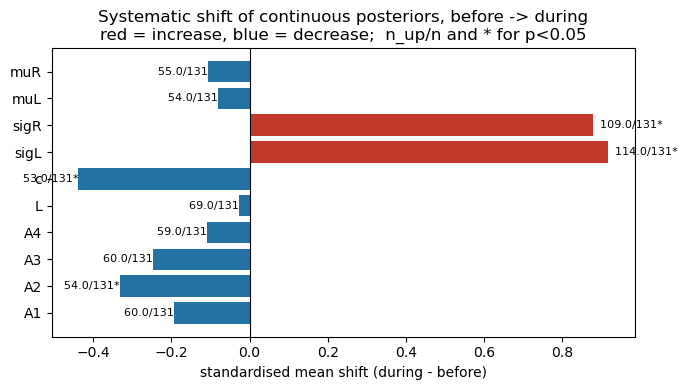

In [9]:
s = shift_mean.set_index("param").reindex(PARAMS).dropna(subset=["delta"])
# normalise each delta by the parameter's overall spread so they are comparable
scale = post[[f"{p}_mean" for p in s.index]].std().values
rel = s["delta"].values / scale

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#c0392b" if d > 0 else "#2471a3" for d in rel]
ax.barh(range(len(s)), rel, color=colors)
ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index)
ax.axvline(0, color="k", lw=0.8)
for i, (prm, row) in enumerate(s.iterrows()):
    star = "*" if row["wilcoxon_p"] < 0.05 else ""
    ax.text(rel[i], i, f"  {row['n_up']}/{int(row['n'])}{star}",
            va="center", ha="left" if rel[i] >= 0 else "right", fontsize=8)
ax.set_xlabel("standardised mean shift (during - before)")
ax.set_title("Systematic shift of continuous posteriors, before -> during\n"
             "red = increase, blue = decrease;  n_up/n and * for p<0.05")
fig.tight_layout()
fig.savefig("figures/ALL_continuous_shift_summary.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Reading the result

- A row of `shift_mean` / `shift_mean_pat` with a small `wilcoxon_p` **and** an
  `n_up` close to `0` or `n` is a parameter that moves **consistently** in one
  direction at seizure onset — the continuous-parameter analogue of the
  inter-hemispheric edge loss in Chapter 6.
- Watch $A_1\dots A_4$ especially: a systematic rise in the excitatory gain
  during seizure is what the model's excitation--inhibition mechanism predicts.
- `shift_sd` says whether the posteriors also sharpen or widen during seizure.

Report the significant, consistent parameters in the results chapter, and note
honestly any that show no systematic shift.
